# CENG428 Neural Networks – Homework 1 & 2
## Circle Detection in 2D Point Clouds

**Task:** Given a variable-length set of 2D points, predict:
1. **Circle existence** — binary (1 value)
2. **Thickness class** — thin / medium / thick (3 softmax scores)
3. **Circle parameters** — cx, cy, r (3 values)

**Architecture strategy:**
- Hand-crafted + learned statistical features from the point set → fixed-size representation
- Shared MLP backbone + three task heads
- Multi-task masked loss (thickness & geometry only when circle exists)
- Data augmentation (rotation, reflection) for regularisation


In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import math

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)
print("PyTorch version:", torch.__version__)


Using device: cpu
PyTorch version: 2.12.0+cu130


## 1. Feature Engineering

We extract a **rich fixed-size descriptor** from the variable-length point set that captures the statistical structure a circle produces:

| Group | Features | Rationale |
|-------|----------|-----------|
| Basic stats | mean, std, min, max of x and y | global point distribution |
| Centroid distances | mean, std, skew, kurtosis, min, max | on-circle → very low std of distances |
| Angular histogram | 16 bins (uniform –π…π) | on-circle → uniform angular spread |
| Radial histogram | 16 bins (0…√2) | on-circle → sharp peak |
| PCA | 2 eigenvalues | elongation / circularity |
| Higher order | 3rd & 4th moments of x,y | shape cues |


In [2]:
def extract_features(pts: np.ndarray, n_angle_bins=16, n_radial_bins=16) -> np.ndarray:
    """
    Extract a fixed-size feature vector from a variable-length (N,2) point array.
    Returns a 1-D numpy array of length = 8 + n_angle_bins + n_radial_bins + 2 + 4 = 46 by default.
    """
    x, y = pts[:, 0], pts[:, 1]
    feats = []

    # ── 1. Basic coordinate stats (8) ────────────────────────────────────────
    for coord in [x, y]:
        feats += [coord.mean(), coord.std() + 1e-8,
                  coord.min(),  coord.max()]

    # ── 2. Centroid-relative distance stats (6) ──────────────────────────────
    cx, cy = x.mean(), y.mean()
    dx, dy = x - cx, y - cy
    dists  = np.sqrt(dx**2 + dy**2)
    d_mean = dists.mean() + 1e-8
    feats += [dists.mean(), dists.std() / (d_mean),         # mean, normalised std
              float(np.mean((dists - dists.mean())**3) / (dists.std()+1e-8)**3),  # skew
              float(np.mean((dists - dists.mean())**4) / (dists.std()+1e-8)**4),  # kurtosis
              dists.min() / (d_mean), dists.max() / (d_mean)]

    # ── 3. Angular histogram (n_angle_bins) ──────────────────────────────────
    angles  = np.arctan2(dy, dx)
    a_hist, _ = np.histogram(angles, bins=n_angle_bins, range=(-np.pi, np.pi))
    a_hist  = a_hist.astype(float)
    a_hist  /= (a_hist.sum() + 1e-8)
    feats   += a_hist.tolist()

    # ── 4. Radial histogram (n_radial_bins) ──────────────────────────────────
    r_hist, _ = np.histogram(dists / (d_mean), bins=n_radial_bins, range=(0, 3))
    r_hist  = r_hist.astype(float)
    r_hist  /= (r_hist.sum() + 1e-8)
    feats   += r_hist.tolist()

    # ── 5. PCA eigenvalues (2) ───────────────────────────────────────────────
    C = np.cov(np.stack([x, y]))
    eigvals = np.linalg.eigvalsh(C)
    eigvals = np.sort(eigvals)[::-1]
    feats  += (eigvals / (eigvals.sum() + 1e-8)).tolist()

    # ── 6. 3rd & 4th moments of x, y (4) ────────────────────────────────────
    for coord in [x, y]:
        s = coord.std() + 1e-8
        feats += [float(np.mean(((coord - coord.mean())/s)**3)),
                  float(np.mean(((coord - coord.mean())/s)**4))]

    return np.array(feats, dtype=np.float32)


# Quick sanity check
sample = np.random.randn(100, 2).astype(np.float32)
f = extract_features(sample)
print("Feature vector length:", len(f))
print("Sample feature values:", f[:8])


Feature vector length: 52
Sample feature values: [-0.11556426  0.85202086 -2.619745    1.8861859   0.03402232  0.99385166
 -1.9875689   2.720169  ]


## 2. Dataset with Augmentation

In [3]:
class CircleDataset(Dataset):
    def __init__(self, npz_path, augment=False):
        data = np.load(npz_path, allow_pickle=True)
        self.points  = data['points']    # (N,) of (n_i, 2) arrays
        self.targets = data['targets7']  # (N, 7)
        self.augment = augment

    def __len__(self):
        return len(self.points)

    def _augment(self, pts, tgt):
        """Random rotation + reflection, keeping targets consistent."""
        # Random rotation
        angle = np.random.uniform(0, 2 * np.pi)
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        R = np.array([[cos_a, -sin_a], [sin_a, cos_a]], dtype=np.float32)
        pts = (R @ pts.T).T

        exists = tgt[0]
        if exists:
            cx, cy, r = tgt[4], tgt[5], tgt[6]
            new_center = R @ np.array([cx, cy], dtype=np.float32)
            tgt = tgt.copy()
            tgt[4], tgt[5] = new_center[0], new_center[1]

        # Random reflection (50 % chance on x-axis)
        if np.random.rand() < 0.5:
            pts[:, 0] = -pts[:, 0]
            if exists:
                tgt = tgt.copy()
                tgt[4] = -tgt[4]

        return pts, tgt

    def __getitem__(self, idx):
        pts = self.points[idx].copy()    # (n, 2)
        tgt = self.targets[idx].copy()   # (7,)

        if self.augment:
            pts, tgt = self._augment(pts, tgt)

        feat = extract_features(pts)     # fixed-size vector
        return (torch.tensor(feat, dtype=torch.float32),
                torch.tensor(tgt,  dtype=torch.float32))


# Quick check
ds_check = CircleDataset('dataset_all.npz', augment=False)
feat0, tgt0 = ds_check[0]
print(f"Dataset size: {len(ds_check)}")
print(f"Feature shape: {feat0.shape},  Target shape: {tgt0.shape}")
print(f"Sample target: {tgt0.numpy()}")


Dataset size: 400
Feature shape: torch.Size([52]),  Target shape: torch.Size([7])
Sample target: [0. 0. 0. 1. 0. 0. 0.]


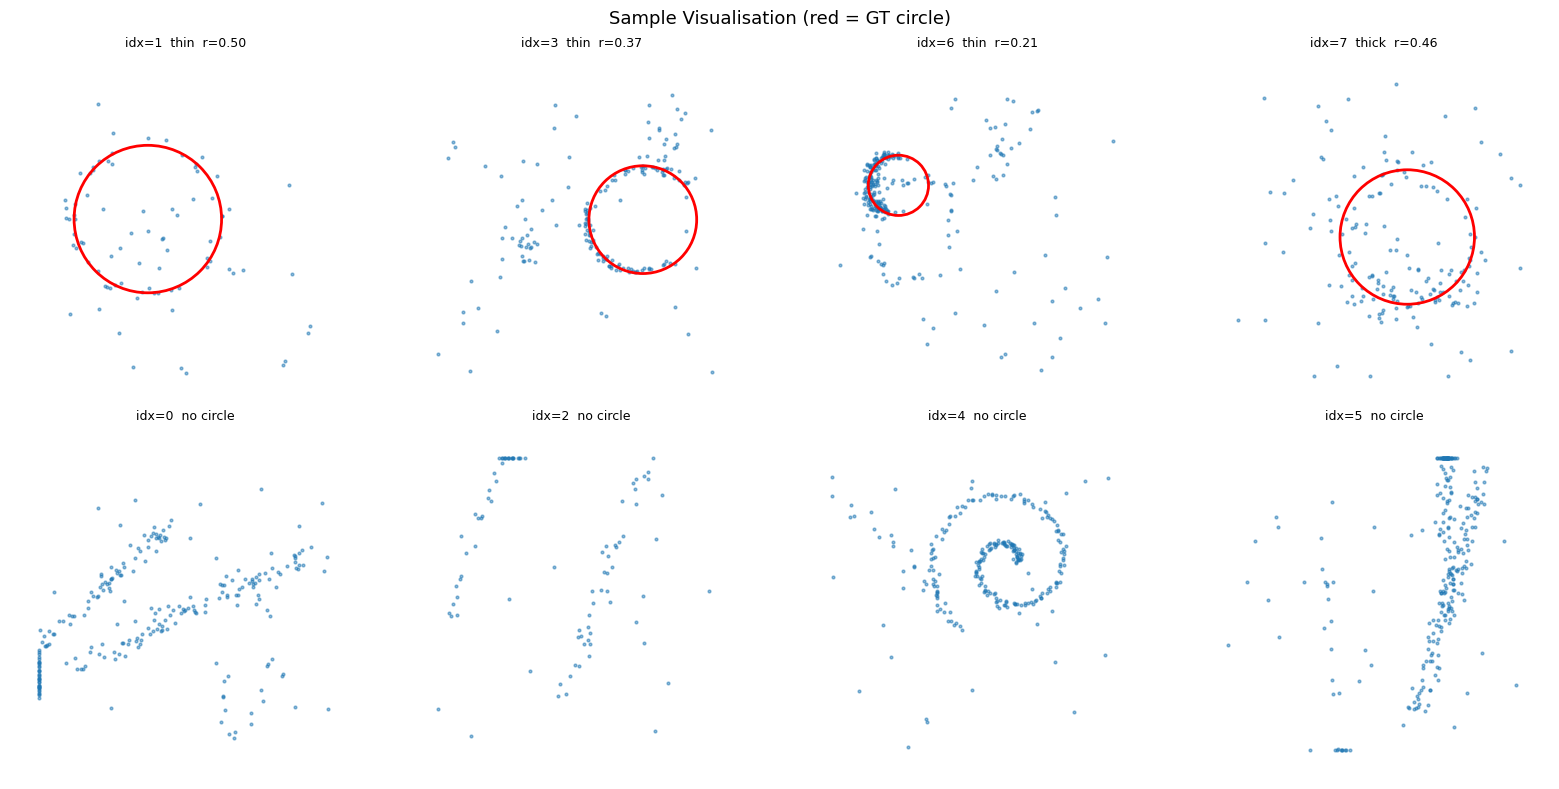

Saved: sample_visualisation.png


In [4]:
# Visualise 8 samples (4 with circles, 4 without)
raw_data = np.load('dataset_all.npz', allow_pickle=True)
all_pts = raw_data['points']
all_tgt = raw_data['targets7']

pos_idx = np.where(all_tgt[:, 0] == 1)[0][:4]
neg_idx = np.where(all_tgt[:, 0] == 0)[0][:4]
idxs    = list(pos_idx) + list(neg_idx)
labels  = ['thin', 'medium', 'thick']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, idx in zip(axes.flatten(), idxs):
    pts, tgt = all_pts[idx], all_tgt[idx]
    ax.scatter(pts[:, 0], pts[:, 1], s=4, alpha=0.5)
    if tgt[0] == 1:
        cx, cy, r = tgt[4], tgt[5], tgt[6]
        th = labels[int(tgt[1:4].argmax())]
        circle = plt.Circle((cx, cy), r, fill=False, color='red', lw=2)
        ax.add_patch(circle)
        ax.set_title(f'idx={idx}  {th}  r={r:.2f}', fontsize=9)
    else:
        ax.set_title(f'idx={idx}  no circle', fontsize=9)
    ax.set_xlim(-1.2, 1.2); ax.set_ylim(-1.2, 1.2)
    ax.set_aspect('equal'); ax.axis('off')
plt.suptitle('Sample Visualisation (red = GT circle)', fontsize=13)
plt.tight_layout()
plt.savefig('sample_visualisation.png', dpi=100)
plt.show()
print("Saved: sample_visualisation.png")


## 3. Model Architecture

```
Feature vector (46-d)
        ↓
  Shared MLP
  Linear(46→256) → BN → ReLU → Dropout(0.4)
  Linear(256→256) → BN → ReLU → Dropout(0.3)
  Linear(256→128) → BN → ReLU
        ↓
  ┌─────────────────┬──────────────────┬──────────────────┐
  ↓                 ↓                  ↓
Exist head       Thickness head    Circle params head
Linear(128→1)    Linear(128→3)     Linear(128→64)→ReLU
(sigmoid)        (softmax/CE)       →Linear(64→3)
```


In [5]:
class CircleNet(nn.Module):
    """
    Multi-task MLP for circle detection from fixed feature vectors.

    Outputs (B, 7):
      [0]   : existence logit  (sigmoid → probability)
      [1:4] : thickness logits (softmax / CE loss)
      [4:7] : circle params    (cx, cy, r – raw regression)
    """

    def __init__(self, in_dim=46, hidden=256, feat_out=128):
        super().__init__()

        # Shared backbone
        self.backbone = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(hidden, feat_out),
            nn.BatchNorm1d(feat_out),
            nn.ReLU(),
        )

        # Task heads
        self.head_exist  = nn.Linear(feat_out, 1)

        self.head_thick  = nn.Sequential(
            nn.Linear(feat_out, 64),
            nn.ReLU(),
            nn.Linear(64, 3),
        )

        self.head_circle = nn.Sequential(
            nn.Linear(feat_out, 64),
            nn.ReLU(),
            nn.Linear(64, 3),
        )

    def forward(self, x):
        feat   = self.backbone(x)                         # (B, feat_out)
        exist  = self.head_exist(feat)                    # (B, 1)
        thick  = self.head_thick(feat)                    # (B, 3)
        circle = self.head_circle(feat)                   # (B, 3)
        return torch.cat([exist, thick, circle], dim=1)   # (B, 7)


# Verify
_test_input = torch.randn(4, 46)
_net = CircleNet()
_out = _net(_test_input)
assert _out.shape == (4, 7), f"Expected (4,7), got {_out.shape}"
total_params = sum(p.numel() for p in _net.parameters() if p.requires_grad)
print(f"Model parameters: {total_params:,}")
print(_net)


Model parameters: 129,031
CircleNet(
  (backbone): Sequential(
    (0): Linear(in_features=46, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
  )
  (head_exist): Linear(in_features=128, out_features=1, bias=True)
  (head_thick): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=3, bias=True)
  )
  (head_circle): Sequential(
    (0): Linear(in_features=128, out_features=64, bias

## 4. Multi-Task Loss

$$\mathcal{L} = w_{exist}\cdot\mathcal{L}_{BCE} + w_{thick}\cdot\mathcal{L}_{CE}^{[e=1]} + w_{circle}\cdot\mathcal{L}_{MSE}^{[e=1]}$$

Thickness and circle losses are **masked** — only applied on samples where the ground-truth circle exists.


In [6]:
class MultiTaskLoss(nn.Module):
    def __init__(self, w_exist=1.0, w_thick=1.0, w_circle=5.0):
        super().__init__()
        self.w_exist  = w_exist
        self.w_thick  = w_thick
        self.w_circle = w_circle
        self.bce      = nn.BCEWithLogitsLoss()
        self.ce       = nn.CrossEntropyLoss()
        self.mse      = nn.MSELoss()

    def forward(self, preds, targets):
        """
        preds   : (B, 7)  raw logits / regression values
        targets : (B, 7)  ground truth
        Returns : total_loss, (l_exist, l_thick, l_circle) — all Python floats
        """
        exist_pred  = preds[:, 0]
        thick_pred  = preds[:, 1:4]
        circle_pred = preds[:, 4:7]

        exist_gt    = targets[:, 0]
        thick_gt    = targets[:, 1:4]
        circle_gt   = targets[:, 4:7]

        # Existence loss — all samples
        l_exist = self.bce(exist_pred, exist_gt)

        # Mask to circle-present samples
        mask = exist_gt.bool()
        if mask.sum() == 0:
            return self.w_exist * l_exist, (l_exist.item(), 0.0, 0.0)

        thick_class = thick_gt[mask].argmax(dim=1)         # class indices
        l_thick  = self.ce(thick_pred[mask], thick_class)
        l_circle = self.mse(circle_pred[mask], circle_gt[mask])

        total = (self.w_exist  * l_exist
               + self.w_thick  * l_thick
               + self.w_circle * l_circle)

        return total, (l_exist.item(), l_thick.item(), l_circle.item())


## 5. Training Pipeline

In [7]:
# ── Hyperparameters ──────────────────────────────────────────────────────────
EPOCHS      = 150
BATCH_SIZE  = 32
LR          = 5e-4
VAL_SPLIT   = 0.2
W_EXIST     = 1.0
W_THICK     = 1.0
W_CIRCLE    = 5.0

# ── Datasets ─────────────────────────────────────────────────────────────────
full_ds = CircleDataset('dataset_all.npz', augment=False)
n_val   = int(len(full_ds) * VAL_SPLIT)
n_train = len(full_ds) - n_val

# Fix the split indices so augmentation is only on train
rng   = torch.Generator().manual_seed(42)
train_idx, val_idx = random_split(range(len(full_ds)), [n_train, n_val],
                                  generator=rng)

class SubsetWithAugment(Dataset):
    def __init__(self, base_ds, indices, augment=False):
        self.base_ds = CircleDataset('dataset_all.npz', augment=augment)
        self.indices = list(indices)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        return self.base_ds[self.indices[i]]

train_ds = SubsetWithAugment(full_ds, train_idx, augment=True)
val_ds   = SubsetWithAugment(full_ds, val_idx,   augment=False)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
print(f"Train: {len(train_ds)}  |  Val: {len(val_ds)}")

# ── Model / optimiser / scheduler ────────────────────────────────────────────
feat_dim  = extract_features(full_ds.points[0]).shape[0]
model     = CircleNet(in_dim=feat_dim, hidden=256, feat_out=128).to(device)
criterion = MultiTaskLoss(W_EXIST, W_THICK, W_CIRCLE)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS,
    steps_per_epoch=len(train_loader), pct_start=0.1)
print(f"Feature dim: {feat_dim}")


Train: 320  |  Val: 80


Feature dim: 52


In [8]:
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    tot = te = tt = tc = 0.0
    n = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for feat, tgt in loader:
            feat, tgt = feat.to(device), tgt.to(device)
            preds = model(feat)
            loss, (le, lt, lc) = criterion(preds, tgt)
            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                scheduler.step()
            tot += loss.item(); te += le; tt += lt; tc += lc; n += 1
    return tot/n, te/n, tt/n, tc/n


history = {k: [] for k in
           ['train_loss','val_loss',
            'train_exist','val_exist',
            'train_thick','val_thick',
            'train_circle','val_circle']}

best_val_loss = float('inf')
best_state    = None

for epoch in range(1, EPOCHS + 1):
    tl, te, tt, tc = run_epoch(train_loader, train=True)
    vl, ve, vt, vc = run_epoch(val_loader,   train=False)

    for k, v in zip(history.keys(), [tl,vl,te,ve,tt,vt,tc,vc]):
        history[k].append(v)

    if vl < best_val_loss:
        best_val_loss = vl
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    if epoch % 15 == 0 or epoch == 1:
        print(f"Ep {epoch:3d}/{EPOCHS} | "
              f"Train {tl:.4f} (E:{te:.3f} T:{tt:.3f} C:{tc:.3f}) | "
              f"Val   {vl:.4f} (E:{ve:.3f} T:{vt:.3f} C:{vc:.3f})")

print(f"\nBest val loss: {best_val_loss:.4f}")
model.load_state_dict(best_state)
torch.save(model.state_dict(), 'circle_net_best.pth')
print("Saved: circle_net_best.pth")


Ep   1/150 | Train 2.7525 (E:0.677 T:1.117 C:0.192) | Val   2.4395 (E:0.673 T:1.093 C:0.135)


Ep  15/150 | Train 1.8178 (E:0.527 T:1.095 C:0.039) | Val   1.7807 (E:0.575 T:1.095 C:0.022)


Ep  30/150 | Train 1.7410 (E:0.515 T:1.087 C:0.028) | Val   1.6270 (E:0.482 T:1.064 C:0.016)


Ep  45/150 | Train 1.6492 (E:0.462 T:1.063 C:0.025) | Val   1.5845 (E:0.435 T:1.065 C:0.017)


Ep  60/150 | Train 1.6225 (E:0.451 T:1.050 C:0.024) | Val   1.5473 (E:0.413 T:1.052 C:0.016)


...

Ep  90/150 | Train 1.5805 (E:0.428 T:1.043 C:0.022) | Val   1.5236 (E:0.406 T:1.045 C:0.015)


Ep 105/150 | Train 1.6187 (E:0.460 T:1.041 C:0.024) | Val   1.4997 (E:0.393 T:1.037 C:0.014)


Ep 120/150 | Train 1.5722 (E:0.450 T:1.016 C:0.021) | Val   1.4990 (E:0.396 T:1.031 C:0.015)


Ep 135/150 | Train 1.5404 (E:0.427 T:0.995 C:0.024) | Val   1.4932 (E:0.394 T:1.028 C:0.014)


Ep 150/150 | Train 1.5509 (E:0.431 T:1.017 C:0.021) | Val   1.4962 (E:0.392 T:1.033 C:0.014)

Best val loss: 1.4883
Saved: circle_net_best.pth


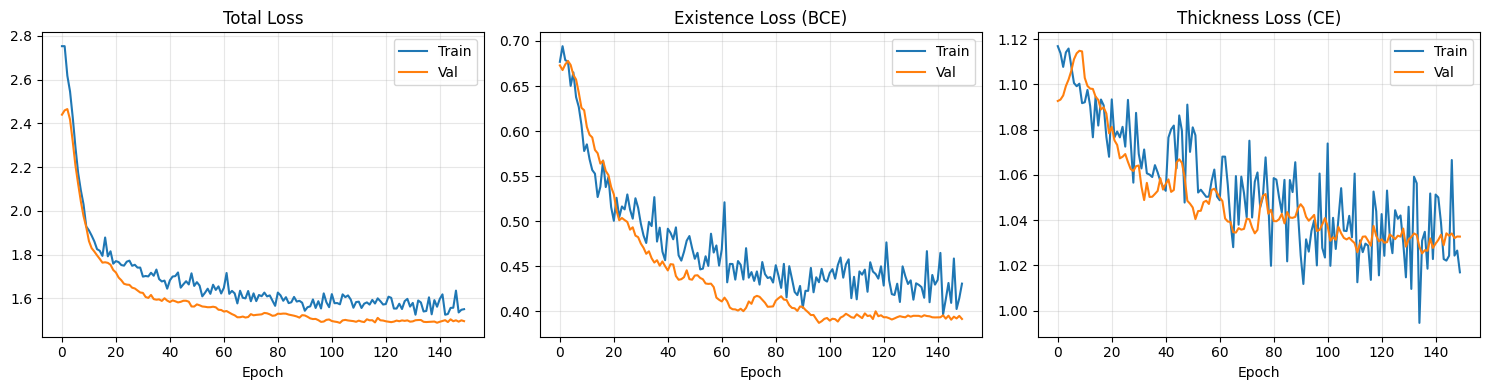

Saved: training_curves.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (tk, vk, title) in zip(axes, [
    ('train_loss',   'val_loss',    'Total Loss'),
    ('train_exist',  'val_exist',   'Existence Loss (BCE)'),
    ('train_thick',  'val_thick',   'Thickness Loss (CE)'),
]):
    ax.plot(history[tk], label='Train')
    ax.plot(history[vk], label='Val')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=100)
plt.show()
print("Saved: training_curves.png")


## 6. Validation Performance

In [10]:
model.eval()

all_ep, all_eg = [], []
all_tp, all_tg = [], []
all_cp, all_cg = [], []

with torch.no_grad():
    for feat, tgt in val_loader:
        feat, tgt = feat.to(device), tgt.to(device)
        preds = model(feat)

        ep = torch.sigmoid(preds[:, 0])
        tp = preds[:, 1:4].argmax(dim=1)
        cp = preds[:, 4:7]

        all_ep.append(ep.cpu()); all_eg.append(tgt[:, 0].cpu())

        mask = tgt[:, 0].bool()
        if mask.sum():
            all_tp.append(tp[mask].cpu())
            all_tg.append(tgt[mask, 1:4].argmax(dim=1).cpu())
            all_cp.append(cp[mask].cpu())
            all_cg.append(tgt[mask, 4:7].cpu())

exist_pred = torch.cat(all_ep); exist_gt = torch.cat(all_eg)
thick_pred = torch.cat(all_tp); thick_gt = torch.cat(all_tg)
circ_pred  = torch.cat(all_cp); circ_gt  = torch.cat(all_cg)

exist_acc = ((exist_pred >= 0.5).float() == exist_gt).float().mean().item()
thick_acc = (thick_pred == thick_gt).float().mean().item()
mae       = (circ_pred - circ_gt).abs().mean(dim=0)

print("=" * 48)
print("  VALIDATION PERFORMANCE")
print("=" * 48)
print(f"  Existence Accuracy : {exist_acc*100:.2f}%")
print(f"  Thickness Accuracy : {thick_acc*100:.2f}%  (circles only)")
print(f"  MAE cx             : {mae[0]:.4f}")
print(f"  MAE cy             : {mae[1]:.4f}")
print(f"  MAE r              : {mae[2]:.4f}")
print(f"  MAE (mean cx,cy,r) : {mae.mean():.4f}")
print("=" * 48)


  VALIDATION PERFORMANCE
  Existence Accuracy : 86.25%
  Thickness Accuracy : 44.44%  (circles only)
  MAE cx             : 0.0984
  MAE cy             : 0.1030
  MAE r              : 0.0639
  MAE (mean cx,cy,r) : 0.0884


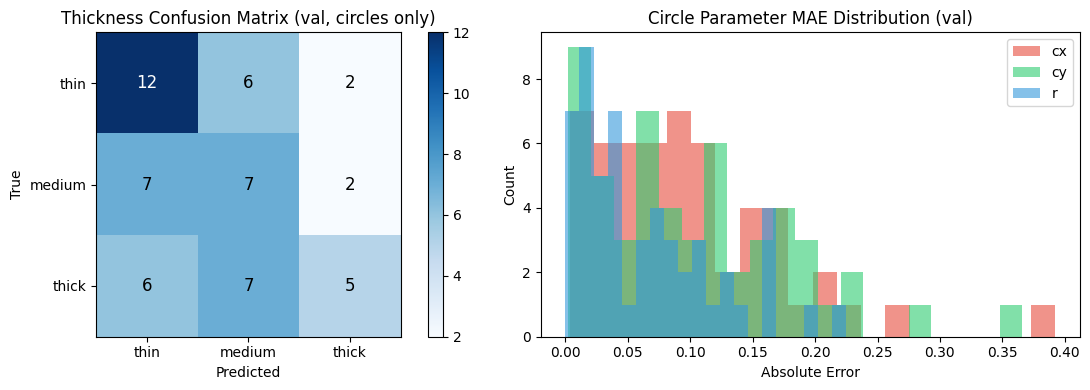

Saved: val_metrics.png


In [11]:
# Thickness confusion matrix
thickness_names = ['thin', 'medium', 'thick']
conf = np.zeros((3, 3), dtype=int)
for p, g in zip(thick_pred.numpy(), thick_gt.numpy()):
    conf[int(g), int(p)] += 1

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
ax = axes[0]
im = ax.imshow(conf, cmap='Blues')
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels(thickness_names); ax.set_yticklabels(thickness_names)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Thickness Confusion Matrix (val, circles only)')
for i in range(3):
    for j in range(3):
        ax.text(j, i, conf[i,j], ha='center', va='center',
                color='white' if conf[i,j]>conf.max()*0.6 else 'black', fontsize=12)
plt.colorbar(im, ax=ax)

# Circle parameter error scatter
ax = axes[1]
for dim, label, color in zip(range(3), ['cx','cy','r'], ['#e74c3c','#2ecc71','#3498db']):
    err = (circ_pred[:, dim] - circ_gt[:, dim]).abs().numpy()
    ax.hist(err, bins=20, alpha=0.6, label=label, color=color)
ax.set_xlabel('Absolute Error'); ax.set_ylabel('Count')
ax.set_title('Circle Parameter MAE Distribution (val)'); ax.legend()

plt.tight_layout()
plt.savefig('val_metrics.png', dpi=100)
plt.show()
print("Saved: val_metrics.png")


## 7. Testing Phase

Load the separate test `.npz` files and run inference. This is exactly how the grading test set will be evaluated.


In [12]:
def load_test_samples(npz_paths):
    """Load test samples from a list of .npz file paths."""
    samples = []
    for path in npz_paths:
        d   = np.load(path, allow_pickle=True)
        pts = d['points']                        # (n, 2) numpy
        samples.append(pts)
    return samples


def predict_samples(model, samples):
    """
    Predict on a list of variable-length (n,2) arrays.
    Returns list of result dicts, each with full 7-value output.
    """
    model.eval()
    results = []
    thickness_names = ['thin', 'medium', 'thick']

    for pts in samples:
        feat = extract_features(pts)
        feat_t = torch.tensor(feat, dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            pred = model(feat_t)[0]    # (7,)

        exist_prob   = torch.sigmoid(pred[0]).item()
        thick_probs  = torch.softmax(pred[1:4], dim=0).cpu().numpy()
        thick_class  = int(thick_probs.argmax())
        cx, cy, r    = pred[4].item(), pred[5].item(), pred[6].item()

        results.append({
            'exists_prob':      exist_prob,
            'exists':           int(exist_prob >= 0.5),
            'thickness_scores': thick_probs,
            'thickness_class':  thick_class,
            'thickness_name':   thickness_names[thick_class],
            'cx': cx, 'cy': cy, 'r': r,
            'target7': [exist_prob, *thick_probs.tolist(), cx, cy, r],
        })

    return results


In [13]:
import glob, os

test_files  = sorted(glob.glob('sample_*.npz'))
print(f"Found {len(test_files)} test files.")

if not test_files:
    print("No sample_*.npz files found. Adjust the glob pattern to point at your test data.")
else:
    test_samples = load_test_samples(test_files)
    predictions  = predict_samples(model, test_samples)

    # ── Formatted results ─────────────────────────────────────────────────────
    print(f"\n{'File':<22} {'Exists':>7} {'Prob':>6} {'Thickness':>10} {'cx':>7} {'cy':>7} {'r':>7}")
    print("-" * 70)
    for fname, pred in zip(test_files, predictions):
        e  = pred['exists']
        pr = f"{pred['exists_prob']:.3f}"
        th = pred['thickness_name'] if e else '–'
        cx = f"{pred['cx']:.3f}"   if e else '–'
        cy = f"{pred['cy']:.3f}"   if e else '–'
        r  = f"{pred['r']:.3f}"    if e else '–'
        print(f"{os.path.basename(fname):<22} {e:>7} {pr:>6} {th:>10} {cx:>7} {cy:>7} {r:>7}")


Found 11 test files.

File                    Exists   Prob  Thickness      cx      cy       r
----------------------------------------------------------------------
sample_00000.npz             0  0.071          –       –       –       –
sample_00001.npz             1  0.939       thin  -0.321  -0.020   0.444
sample_00002.npz             1  0.558      thick  -0.116   0.217   0.541
sample_00003.npz             1  0.903      thick   0.240   0.096   0.439
sample_00004.npz             1  0.718      thick   0.182   0.255   0.328
sample_00005.npz             1  0.613     medium   0.355   0.443   0.193
sample_00006.npz             1  0.911     medium  -0.538   0.245   0.226
sample_00007.npz             1  0.976       thin   0.153  -0.214   0.460
sample_00008.npz             0  0.380          –       –       –       –
sample_00009.npz             0  0.370          –       –       –       –
sample_00010.npz             1  0.849      thick  -0.326  -0.476   0.290


In [14]:
# ── Compare with ground truth ─────────────────────────────────────────────────
print("\nGround truth comparison:")
print(f"{'File':<20} {'GT_E':>5} {'PR_E':>5} {'GT_Th':>8} {'PR_Th':>8} {'GT_cx':>7} {'PR_cx':>7} {'GT_r':>6} {'PR_r':>6}")
print("-" * 78)
thickness_names = ['thin','medium','thick']

for fname, pred in zip(test_files, predictions):
    d   = np.load(fname, allow_pickle=True)
    gt  = d['target7']
    gt_e  = int(gt[0])
    gt_th = thickness_names[int(gt[1:4].argmax())] if gt_e else '–'
    gt_cx = f"{gt[4]:.3f}" if gt_e else '–'
    gt_r  = f"{gt[6]:.3f}" if gt_e else '–'
    pr_e  = pred['exists']
    pr_th = pred['thickness_name'] if pr_e else '–'
    pr_cx = f"{pred['cx']:.3f}" if pr_e else '–'
    pr_r  = f"{pred['r']:.3f}"  if pr_e else '–'
    ok    = '✓' if gt_e == pr_e else '✗'
    print(f"{os.path.basename(fname):<20} {gt_e:>5} {pr_e:>4}{ok}"
          f" {gt_th:>8} {pr_th:>8} {gt_cx:>7} {pr_cx:>7} {gt_r:>6} {pr_r:>6}")



Ground truth comparison:
File                  GT_E  PR_E    GT_Th    PR_Th   GT_cx   PR_cx   GT_r   PR_r
------------------------------------------------------------------------------
sample_00000.npz         0    0✓        –        –       –       –      –      –
sample_00001.npz         1    1✓     thin     thin  -0.256  -0.321  0.505  0.444
sample_00002.npz         0    1✗        –    thick       –  -0.116      –  0.541
sample_00003.npz         1    1✓     thin    thick   0.420   0.240  0.369  0.439
sample_00004.npz         0    1✗        –    thick       –   0.182      –  0.328
sample_00005.npz         0    1✗        –   medium       –   0.355      –  0.193
sample_00006.npz         1    1✓     thin   medium  -0.543  -0.538  0.206  0.226
sample_00007.npz         1    1✓    thick     thin   0.228   0.153  0.460  0.460
sample_00008.npz         0    0✓        –        –       –       –      –      –
sample_00009.npz         0    0✓        –        –       –       –      –      –
samp

In [15]:
# ── Save predictions ──────────────────────────────────────────────────────────
if test_files:
    pred_array = np.array([p['target7'] for p in predictions], dtype=np.float32)
    np.savez('test_predictions.npz',
             predictions=pred_array,
             files=np.array(test_files))
    print(f"\nSaved → test_predictions.npz  shape={pred_array.shape}")
    print("Columns: [exists_prob, thin_score, med_score, thick_score, cx, cy, r]")



Saved → test_predictions.npz  shape=(11, 7)
Columns: [exists_prob, thin_score, med_score, thick_score, cx, cy, r]
